1. Remove asr, directly use ground truth transcription originally from the dataset, to classify textual sentiment.
    - clarify and mention this limitation in the paper.

# Section 0. Setup
- Experiment settings (constants)

In [18]:
import os
import gc
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.utils import class_weight
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from tqdm import tqdm
import whisper
from transformers import pipeline
import torch
from collections import defaultdict
from datetime import datetime

# Reproducibility for Reviewer Validation
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

class Config:
    # Data Settings
    DATA_PATH = 'dataset_meld/'
    FILE_PREFIX = 'prepared_'
    SR = 16000
    MAX_DURATION = 3
    MAX_SAMPLES = SR * MAX_DURATION
    
    # Feature Settings
    N_MFCC = 40
    MAX_MFCC_LEN = 94  
    
    # Training Parameters 
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001
    EPOCHS = 50
    DROPOUT = 0.3
    
    DEFAULT_CLASSES = ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']

print("=== Hyperparameters ===")
for k, v in vars(Config).items():
    if not k.startswith('__'): print(f"{k}: {v}")

=== Hyperparameters ===
DATA_PATH: dataset_meld/
FILE_PREFIX: prepared_
SR: 16000
MAX_DURATION: 3
MAX_SAMPLES: 48000
N_MFCC: 40
MAX_MFCC_LEN: 94
BATCH_SIZE: 32
LEARNING_RATE: 0.001
EPOCHS: 50
DROPOUT: 0.3
DEFAULT_CLASSES: ['neutral', 'joy', 'sadness', 'anger', 'fear', 'disgust', 'surprise']


In [2]:
import shutil
import imageio_ffmpeg

# 1. Get the directory where imageio_ffmpeg stores its binary
ffmpeg_bin_dir = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())

# 2. Whisper looks specifically for "ffmpeg.exe". Let's make sure a copy exists with that exact name.
target_exe = os.path.join(ffmpeg_bin_dir, "ffmpeg.exe")
if not os.path.exists(target_exe):
    shutil.copy(imageio_ffmpeg.get_ffmpeg_exe(), target_exe)

# 3. Inject this directory into the system PATH for this session
os.environ["PATH"] += os.pathsep + ffmpeg_bin_dir

### Setup with GPU

In [3]:
import torch
print(torch.__version__)

2.11.0+cu128


In [4]:
# 1. Check GPU availability and set up device formatting
cuda_available = torch.cuda.is_available()
target_device = "cuda" if cuda_available else "cpu"
hf_device = 0 if cuda_available else -1

print(f"CUDA Available: {cuda_available}")
if cuda_available:
    print(f"Activating GPU: {torch.cuda.get_device_name(0)}\n")
else:
    print("GPU not detected. Running on CPU instead.\n")

CUDA Available: True
Activating GPU: NVIDIA GeForce RTX 5080 Laptop GPU



# Section 2. Feature Extraction

### 2.1 Textual Sentiment
Exclude ASR, import RoBERTa, classify textual sentiment from transcription

In [5]:
# Load RoBERTa Sentiment Classifier on the target device
print("Loading RoBERTa Sentiment Classifier...")
sentiment_classifier = pipeline(
    "sentiment-analysis", 
    model="cardiffnlp/twitter-roberta-base-sentiment-latest", 
    device=hf_device
)

Loading RoBERTa Sentiment Classifier...


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 50104.31it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



================ TRAIN SPLIT ================

Processing: dataset_meld\train_sent_emo.csv


  0%|          | 0/9989 [00:00<?, ?it/s]

100%|██████████| 9989/9989 [00:56<00:00, 175.78it/s]



✅ Finished train. Saved to dataset_meld\prepared_train_20260713_2030_sent_emo.csv

================ DEV SPLIT ================

Processing: dataset_meld\dev_sent_emo.csv


100%|██████████| 1109/1109 [00:06<00:00, 182.07it/s]



✅ Finished dev. Saved to dataset_meld\prepared_dev_20260713_2030_sent_emo.csv

================ TEST SPLIT ================

Processing: dataset_meld\test_sent_emo.csv


100%|██████████| 2610/2610 [00:14<00:00, 182.08it/s]



✅ Finished test. Saved to dataset_meld\prepared_test_20260713_2030_sent_emo.csv

================ FINAL DATASET REPORT ================

Success samples           : 13706
Missing audio             : 2
Invalid CSV data          : 0
Sentiment prediction fail : 0
TOTAL FAILURES            : 2
------------------------------------------------------
Average Sentiment Score   : 0.7204

Failure log saved: dataset_meld/failed_samples_log_20260713_2030.csv


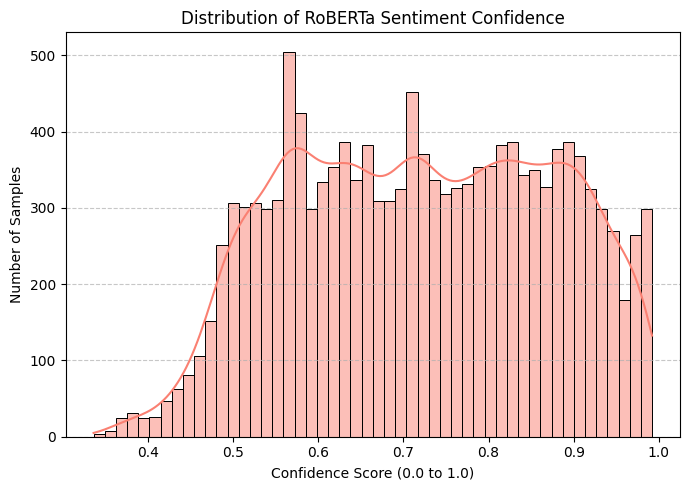

In [7]:
AUDIO_DIRECTORY = "dataset_meld/audio/"
AUDIO_EXT = ".wav"
splits = ['train', 'dev', 'test']

os.makedirs("dataset_meld", exist_ok=True)

# Create a timestamp string for the filenames (e.g., "20260617_2030")
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# --- GLOBAL STATS (per split) ---
stats = defaultdict(int)
failed_samples = []

# Lists to collect data for final graphs
global_sentiment_scores = []

# --- PROCESSING LOOP ---
for split in splits:
    print(f"\n================ {split.upper()} SPLIT ================\n")

    orig_csv = os.path.join("dataset_meld", f"{split}_sent_emo.csv")
    out_csv = os.path.join("dataset_meld", f"prepared_{split}_{timestamp}_sent_emo.csv")

    print(f"Processing: {orig_csv}")
    df = pd.read_csv(orig_csv)

    # --- MOCK RUN MECHANISM ---
    MOCK_MODE = False  # Toggle this to False to run the full dataset
    if MOCK_MODE:
        # Take 10% of the data, sampled randomly
        df = df.sample(frac=0.10, random_state=SEED) 
        print(f"⚠️ MOCK MODE ACTIVE: Processing only 10% of {split} ({len(df)} samples)")
    # --------------------------

    prepared_data = []

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        dia_id = row['Dialogue_ID']
        utt_id = row['Utterance_ID']

        raw_path = os.path.join(
            AUDIO_DIRECTORY,
            f"wav_{split}",
            f"dia{dia_id}_utt{utt_id}{AUDIO_EXT}"
        )
        file_path = os.path.abspath(raw_path)

        # ---------------------------
        # Missing audio
        # ---------------------------
        if not os.path.exists(file_path):
            stats["missing_audio"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "missing_audio"
            })
            continue

        # ---------------------------
        # Validate CSV fields
        # ---------------------------
        if pd.isna(row['Emotion']) or pd.isna(row['Sentiment']) or pd.isna(row['Utterance']):
            stats["invalid_csv_data"] += 1
            failed_samples.append({
                "split": split,
                "file_path": file_path,
                "reason": "invalid_csv_data"
            })
            continue

        emo_gt = str(row['Emotion']).lower()
        sent_gt = str(row['Sentiment']).lower()
        trans_gt = str(row['Utterance']).strip()

        # ---------------------------
        # Sentiment prediction (on ground-truth transcription)
        # ---------------------------
        try:
            bert_out = sentiment_classifier(trans_gt)[0]
            sent_pred = bert_out['label'].lower()
            sent_score = bert_out['score']

        except Exception as e:
            stats["sentiment_failed"] += 1
            failed_samples.append({
                "split": split, "file_path": file_path, "reason": "sentiment_failed", "error": str(e)
            })
            continue

        # ---------------------------
        # SUCCESS CASE
        # ---------------------------
        prepared_data.append({
            'emotion': emo_gt,
            'sentiment': sent_gt,  
            'textual_sentiment_predicted': sent_pred,
            'textual_sentiment_score': sent_score,
            'transcription_ground_truth': trans_gt,
            'file_path': file_path
        })

        stats["success"] += 1
        global_sentiment_scores.append(sent_score)

    # ---------------------------
    # Save entire batch at once (Optimised for GPU speed)
    # ---------------------------
    if prepared_data:
        chunk_df = pd.DataFrame(prepared_data)
        chunk_df.to_csv(out_csv, index=False)

    print(f"\n✅ Finished {split}. Saved to {out_csv}")
# ---------------------------
# FINAL REPORT
# ---------------------------
print("\n================ FINAL DATASET REPORT ================\n")

total_failures = (
    stats["missing_audio"] + stats["invalid_csv_data"] +
    stats["sentiment_failed"]
)

# Calculate Averages
avg_sent = sum(global_sentiment_scores) / len(global_sentiment_scores) if global_sentiment_scores else 0

print(f"Success samples           : {stats['success']}")
print(f"Missing audio             : {stats['missing_audio']}")
print(f"Invalid CSV data          : {stats['invalid_csv_data']}")
print(f"Sentiment prediction fail : {stats['sentiment_failed']}")
print(f"TOTAL FAILURES            : {total_failures}")
print("-" * 54)
print(f"Average Sentiment Score   : {avg_sent:.4f}")

# ---------------------------
# SAVE FAILURE LOG
# ---------------------------
failed_df = pd.DataFrame(failed_samples)
log_filename = f"dataset_meld/failed_samples_log_{timestamp}.csv"
failed_df.to_csv(log_filename, index=False)

print(f"\nFailure log saved: {log_filename}")

# ---------------------------
# GENERATE DISTRIBUTION GRAPH
# ---------------------------
if global_sentiment_scores:
    plt.figure(figsize=(7, 5))

    sns.histplot(global_sentiment_scores, bins=50, kde=True, color='salmon')
    plt.title("Distribution of RoBERTa Sentiment Confidence")
    plt.xlabel("Confidence Score (0.0 to 1.0)")
    plt.ylabel("Number of Samples")
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

### Cross-tabulation: Predicted Textual Sentiment vs. Ground-Truth Emotion

Before interpreting the fusion model's reliance on the text branch, we first quantify how much
information the RoBERTa-predicted sentiment label alone carries about the true emotion class.
We combine the `prepared_{split}_*.csv` outputs from all three splits (train/dev/test) into a
single DataFrame and cross-tabulate `textual_sentiment_predicted` (3 classes: negative/neutral/
positive) against the ground-truth `emotion` label (7 classes). This reveals how cleanly sentiment
separates the emotion classes — i.e., whether the model's heavy reliance on this branch (seen in
the permutation importance experiment) reflects a genuine, clean shortcut or something more nuanced.

In [29]:
import glob

# Combine train, dev, and test prepared data using the saved CSVs from this run
csv_pattern = f"dataset_meld/prepared_*_20260713_2030_sent_emo.csv"
matched_files = sorted(glob.glob(csv_pattern))

print(f"Found {len(matched_files)} files for this run:")
for f in matched_files:
    print(f"  - {f}")

final_df = pd.concat([pd.read_csv(f) for f in matched_files], ignore_index=True)
print(f"\nTotal combined samples: {len(final_df)}")

# Now generate the crosstab across all splits combined
pd.crosstab(final_df['textual_sentiment_predicted'], final_df['emotion'])

Found 3 files for this run:
  - dataset_meld\prepared_dev_20260713_2030_sent_emo.csv
  - dataset_meld\prepared_test_20260713_2030_sent_emo.csv
  - dataset_meld\prepared_train_20260713_2030_sent_emo.csv

Total combined samples: 13706


emotion,anger,disgust,fear,joy,neutral,sadness,surprise
textual_sentiment_predicted,,,,,,,
negative,737,223,163,220,793,521,392
neutral,552,105,141,557,4611,338,822
positive,318,33,54,1531,1030,143,422


#### Analysis 1. The crosstab confirms weak, noisy valence separation — not a clean shortcut.
No emotion is cleanly captured by one sentiment bucket. joy splits 220/557/1531 across neg/neutral/pos (66% positive), anger splits 737/552/318 (only 46% negative), and sadness splits 521/338/143 (52% negative). The dominant behavior is RoBERTa predicting neutral for 52% of all samples regardless of true emotion — consistent with MELD being short, sarcastic sitcom dialogue where lexical content often doesn't carry the emotional charge that prosody does.

### Sentiment-Only Accuracy Ceiling

Using the crosstab above, we compute the best possible accuracy achievable by a classifier that
only has access to the predicted sentiment label — i.e., always predicting the majority emotion
within each sentiment bucket. This gives a hard upper bound on how much *discrete* sentiment
information alone can explain, which we compare against the trivial baseline of always predicting
the single overall majority class (`neutral`). The gap between these two numbers tells us how much
real separating power the 3-class sentiment label adds beyond just guessing the majority class.

In [30]:
# For each predicted sentiment, find the majority emotion and compute how many samples that covers
ct = pd.crosstab(final_df['textual_sentiment_predicted'], final_df['emotion'])
majority_correct = ct.max(axis=1).sum()
total = ct.values.sum()
ceiling_acc = majority_correct / total

print(f"Majority-vote-per-sentiment-bucket accuracy ceiling: {ceiling_acc:.4f}")
print(f"(Sanity check — overall majority class baseline: {final_df['emotion'].value_counts().max() / len(final_df):.4f})")

Majority-vote-per-sentiment-bucket accuracy ceiling: 0.5060
(Sanity check — overall majority class baseline: 0.4694)


#### Analysis 2. The sentiment-only ceiling (0.506) barely beats the naive majority-class baseline (0.469).
That's only a 3.7-point gap. In other words, if the model used only the discrete sentiment label optimally, it could reach at most ~50.6% — and most of that comes from bucket sizes, not genuine class separation. This is a much lower ceiling than the model's actual dev accuracy (~43.6%) would suggest is being driven by sentiment alone, which raises the question you're now testing directly: is the score doing more work than the label?

### Does RoBERTa's Confidence Score Carry Additional Signal?

The discrete sentiment label only explains a small ceiling (see above), yet the neural network's
permutation importance for the text branch was much higher (~11% accuracy drop). Since the text
branch's input includes both the one-hot sentiment label *and* the continuous confidence score
(`textual_sentiment_score`), we check whether the confidence score itself varies systematically
across true emotion classes. If so, the network may be extracting a continuous signal invisible
to the discrete crosstab — which would help explain the discrepancy between the ceiling estimate
and the observed permutation importance.

In [31]:
final_df.groupby('emotion')['textual_sentiment_score'].describe()

,count,mean,std,min,25%,50%,75%,max
emotion,,,,,,,,
anger,1607.0,0.702321,0.155329,0.336125,0.565455,0.710626,0.840204,0.987960
disgust,361.0,0.729509,0.157444,0.384129,0.601389,0.740869,0.876870,0.980323
fear,358.0,0.707836,0.147555,0.397780,0.591693,0.719213,0.837570,0.970829
joy,2308.0,0.783442,0.167111,0.372371,0.650688,0.806207,0.944088,0.990401
neutral,6434.0,0.708186,0.136793,0.340995,0.588020,0.706898,0.823339,0.992003
sadness,1002.0,0.714659,0.153003,0.347885,0.585151,0.726068,0.846509,0.985493
surprise,1636.0,0.701695,0.150226,0.353116,0.583713,0.699888,0.828333,0.987875


#### Analysis 3. The confidence score distributions are the most interesting finding — and they explain the discrepancy.
Looking at the textual_sentiment_score means by emotion. joy stands out with a distinctly higher mean confidence (0.783) than every other emotion (all clustered tightly around 0.70–0.73). This makes sense: joy is also the emotion RoBERTa most confidently and correctly identifies as "positive" (1531/2308 = 66%), so when the model is confident, it's usually right about joy specifically. All the other six emotions have nearly indistinguishable confidence distributions (differences of only ~0.01–0.03 in the mean, with heavily overlapping std), meaning confidence alone doesn't meaningfully separate anger from fear from surprise from neutral.

### 2.2 Acoustic Feature
MFCCs
### 2.3 Statistical Features
chroma, contrast, zcr, rms

In [9]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
SR = 16000
MAX_DURATION = 3
MAX_SAMPLES = SR * MAX_DURATION
N_MFCC = 40
MAX_MFCC_LEN = 94 

previous_timestamp = "20260713_2030"

csv_files = {
    'train': os.path.join(Config.DATA_PATH, f"prepared_train_{previous_timestamp}_sent_emo.csv"),
    'dev': os.path.join(Config.DATA_PATH, f"prepared_dev_{previous_timestamp}_sent_emo.csv"),
    'test': os.path.join(Config.DATA_PATH, f"prepared_test_{previous_timestamp}_sent_emo.csv")
}

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
path = os.path.join(Config.DATA_PATH, f"all_features_{split}_{timestamp}.npz")

print(f"Starting Independent Feature Extraction to NPZ (Timestamp: {timestamp})...\n")

# ==========================================
# 2. EXTRACTION & SAVING LOOP (Per Split)
# ==========================================
for split, path in csv_files.items():
    if not os.path.exists(path):
        print(f"File not found: {path}")
        continue
        
    print(f"Processing {split.upper()} set from {path}")
    df = pd.read_csv(path)
    
    successful_rows = []
    mfcc_data = []
    stats_data = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        file_path = row['file_path']
        
        try:
            # 1. Load Audio
            y, _ = librosa.load(file_path, sr=SR)
            
            # 2. Safeguard against ultra-short clips
            if len(y) < 500:
                continue
                
            # 3. Pad or Crop to exactly 3 seconds
            if len(y) > MAX_SAMPLES:
                y = y[:MAX_SAMPLES]
            else:
                y = np.pad(y, (0, int(MAX_SAMPLES - len(y))), 'constant')
                
            # 4. Extract MFCC
            mfcc = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC).T
            if mfcc.shape[0] > MAX_MFCC_LEN:
                mfcc = mfcc[:MAX_MFCC_LEN, :]
            else:
                mfcc = np.pad(mfcc, ((0, MAX_MFCC_LEN - mfcc.shape[0]), (0, 0)), 'constant')
                
            # 5. Extract Statistical Features
            chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=SR).T, axis=0)
            contrast = np.mean(librosa.feature.spectral_contrast(y=y, sr=SR).T, axis=0)
            zcr = np.mean(librosa.feature.zero_crossing_rate(y=y).T, axis=0)
            rms = np.mean(librosa.feature.rms(y=y).T, axis=0)
            
            stats = np.hstack([chroma, contrast, zcr, rms])
            
            # 6. Append to lists 
            successful_rows.append(row)
            mfcc_data.append(mfcc.flatten())
            stats_data.append(stats)
            
        except Exception as e:
            continue

    # ==========================================
    # 3. BUILD ARRAYS & SAVE FOR THIS SPLIT
    # ==========================================
    if successful_rows:
        print(f"Constructing NPZ archive for {split.upper()}...")
        
        # Convert the original rows back into a DataFrame to format them cleanly
        df_meta = pd.DataFrame(successful_rows).reset_index(drop=True)
        if 'split' not in df_meta.columns:
            df_meta.insert(0, 'split', split)
            
        out_npz = f"dataset_meld/all_features_{split}_{timestamp}.npz"
        print(f"Saving {split.upper()} to {out_npz}...")

        # Convert numerical lists to strict numpy arrays (float32 saves 50% memory)
        np_mfcc = np.array(mfcc_data, dtype=np.float32)
        np_stats = np.array(stats_data, dtype=np.float32)
        
        # Convert metadata to numpy structures
        np_meta = df_meta.to_numpy(dtype=str)
        meta_cols = df_meta.columns.to_numpy(dtype=str)

        # Save as a compressed NumPy archive
        np.savez_compressed(
            out_npz,
            mfcc=np_mfcc,
            stats=np_stats,
            meta=np_meta,
            meta_cols=meta_cols
        )
        print(f"{split.upper()} Matrix shapes -> Meta: {np_meta.shape}, MFCC: {np_mfcc.shape}, Stats: {np_stats.shape}\n")
    else:
        print(f"No valid samples extracted for {split.upper()}.\n")

    # ==========================================
    # 4. MEMORY CLEANUP
    # ==========================================
    del successful_rows, mfcc_data, stats_data, df_meta, np_mfcc, np_stats, np_meta
    gc.collect()

print("All splits processed and saved independently as NPZ archives!")

Starting Independent Feature Extraction to NPZ (Timestamp: 20260713_2043)...

Processing TRAIN set from dataset_meld/prepared_train_20260713_2030_sent_emo.csv


100%|██████████| 9988/9988 [02:14<00:00, 74.38it/s]


Constructing NPZ archive for TRAIN...
Saving TRAIN to dataset_meld/all_features_train_20260713_2043.npz...
TRAIN Matrix shapes -> Meta: (9988, 7), MFCC: (9988, 3760), Stats: (9988, 21)

Processing DEV set from dataset_meld/prepared_dev_20260713_2030_sent_emo.csv


100%|██████████| 1108/1108 [00:15<00:00, 73.51it/s]


Constructing NPZ archive for DEV...
Saving DEV to dataset_meld/all_features_dev_20260713_2043.npz...
DEV Matrix shapes -> Meta: (1108, 7), MFCC: (1108, 3760), Stats: (1108, 21)

Processing TEST set from dataset_meld/prepared_test_20260713_2030_sent_emo.csv


100%|██████████| 2610/2610 [00:34<00:00, 74.63it/s]


Constructing NPZ archive for TEST...
Saving TEST to dataset_meld/all_features_test_20260713_2043.npz...
TEST Matrix shapes -> Meta: (2610, 7), MFCC: (2610, 3760), Stats: (2610, 21)

All splits processed and saved independently as NPZ archives!


# 3.0 Load and Import (features and functions)

### Import NPZs (labels + acoustic features + textual sentiment predicted)

In [10]:
def load_and_prepare_npz(split, timestamp="20260713_2043"):
    path = os.path.join(Config.DATA_PATH, f"all_features_{split}_{timestamp}.npz")
    data = np.load(path, allow_pickle=True)
    
    # Reshape MFCCs back to 2D sequence (Batch, TimeSteps, Features)
    X_mfcc = data['mfcc'].reshape(-1, Config.MAX_MFCC_LEN, Config.N_MFCC)
    X_stats = data['stats']
    
    meta_cols = data['meta_cols'].tolist()
    
    # Extract Target Labels (Emotion)
    emo_idx = meta_cols.index('emotion')
    y_raw = data['meta'][:, emo_idx]
    
    # Extract Textual Sentiment Predicted strings (Bimodal setup)
    pred_idx = meta_cols.index('textual_sentiment_predicted')
    X_text_pred_raw = data['meta'][:, pred_idx]
    
    return X_mfcc, X_stats, X_text_pred_raw, y_raw

print("Loading Data...")
X_train_mfcc, X_train_stats, X_train_txt_raw, y_train_raw = load_and_prepare_npz('train')
X_dev_mfcc, X_dev_stats, X_dev_txt_raw, y_dev_raw = load_and_prepare_npz('dev')
X_test_mfcc, X_test_stats, X_test_txt_raw, y_test_raw = load_and_prepare_npz('test')

# --- ENCODE TARGETS (Emotion) ---
label_encoder = LabelEncoder()
label_encoder.fit(Config.DEFAULT_CLASSES)

y_train = label_encoder.transform(y_train_raw)
y_dev = label_encoder.transform(y_dev_raw)
y_test = label_encoder.transform(y_test_raw)
num_classes = len(Config.DEFAULT_CLASSES)

# --- ENCODE TEXT MODALITY (Sentiment Predictions) ---
# OneHotEncoder transforms 'positive', 'neutral', 'negative' into 2D numerical vectors 
sentiment_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# We reshape to (-1, 1) because OneHotEncoder expects a 2D array matrix 
X_train_txt = sentiment_encoder.fit_transform(X_train_txt_raw.reshape(-1, 1))
X_dev_txt = sentiment_encoder.transform(X_dev_txt_raw.reshape(-1, 1))
X_test_txt = sentiment_encoder.transform(X_test_txt_raw.reshape(-1, 1))

print(f"✅ Data Loaded & Encoded.")
print(f"Train MFCC Shape: {X_train_mfcc.shape}")
print(f"Train Stats Shape: {X_train_stats.shape}")
print(f"Train Text Modality Shape: {X_train_txt.shape} (One-Hot Encoded Sentiment)")

Loading Data...
✅ Data Loaded & Encoded.
Train MFCC Shape: (9988, 94, 40)
Train Stats Shape: (9988, 21)
Train Text Modality Shape: (9988, 3) (One-Hot Encoded Sentiment)


### Evaluation Functions

In [11]:
def plot_training_history(history, model_name):
    """Plots training/validation accuracy and loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Accuracy Plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='blue')
    axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
    axes[0].set_title(f'{model_name} - Model Accuracy')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)
    
    # Loss Plot
    axes[1].plot(history.history['loss'], label='Train Loss', color='blue')
    axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
    axes[1].set_title(f'{model_name} - Model Loss')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

def evaluate_model_performance(model, X_test, y_test, model_name):
    """Generates Classification Report and Percentage-based Confusion Matrix."""
    print(f"\n================ Evaluating {model_name} ================")
    
    # Predictions
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    # 1. Classification Report
    print("\n--- Classification Report ---")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))
    
    # 2. Confusion Matrix (Raw & Percentages)
    cm = confusion_matrix(y_test, y_pred)
    # Calculate percentages across rows (true labels)
    cm_percentages = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_percentages = np.nan_to_num(cm_percentages) # Handle division by zero
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percentages, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cbar_kws={'label': 'Percentage of True Class'})
    plt.title(f'{model_name} - Confusion Matrix (Percentages)')
    plt.ylabel('Ground Truth (True Label)')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

# Section 3. Train and Test

## CNN-LSTM Model (Training & Testing)

In [12]:
# ==========================================
# 1. DEFINE INPUT BRANCHES
# ==========================================
# Branch 1: Acoustic MFCCs (Time-Series)
in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
x_mfcc = layers.Conv1D(64, 3, activation='relu', padding='same')(in_mfcc)
x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
x_mfcc = layers.LSTM(64)(x_mfcc)

# Branch 2: Acoustic Statistical Features (Numeric)
in_stats = layers.Input(shape=(X_train_stats.shape[1],), name="in_stats")
x_stats = layers.Dense(32, activation='relu')(in_stats)
x_stats = layers.BatchNormalization()(x_stats)

# Branch 3: Textual Sentiment (One-Hot Encoded)
in_text = layers.Input(shape=(X_train_txt.shape[1],), name="in_text")
# A Dense layer acts identically to an Embedding layer for one-hot inputs
x_text = layers.Dense(16, activation='relu')(in_text)

# ==========================================
# 2. FUSION AND CLASSIFICATION
# ==========================================
# Concatenate all three modalities
merged = layers.Concatenate()([x_mfcc, x_stats, x_text])

# Fully Connected Layers
x = layers.Dense(128, activation='relu')(merged)
x = layers.Dropout(Config.DROPOUT)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build the final Model
cnn_lstm_model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)

In [19]:
# ==========================================
# 3. COMPILE AND TRAIN
# ==========================================
optimizer = optimizers.Adam(learning_rate=Config.LEARNING_RATE)
cnn_lstm_model.compile(optimizer=optimizer, 
                       loss='sparse_categorical_crossentropy', 
                       metrics=['accuracy'])

print(f"Training for exactly {Config.EPOCHS} epochs...")
history_cnn_lstm = cnn_lstm_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,             
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),     
    epochs=Config.EPOCHS,
    batch_size=Config.BATCH_SIZE,
    verbose=1
)

Training for exactly 50 epochs...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5288 - loss: 1.3337 - val_accuracy: 0.4648 - val_loss: 1.5212
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5279 - loss: 1.3331 - val_accuracy: 0.4612 - val_loss: 1.5361
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5334 - loss: 1.3254 - val_accuracy: 0.4675 - val_loss: 1.5240
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5307 - loss: 1.3205 - val_accuracy: 0.4657 - val_loss: 1.5203
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5352 - loss: 1.3142 - val_accuracy: 0.4522 - val_loss: 1.5663
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5350 - loss: 1.3109 - val_accuracy: 0.4720 - val_loss: 1.5193
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5351 - loss: 1.3121 - val_accuracy: 0.4729 - val_loss: 1.5376
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.535

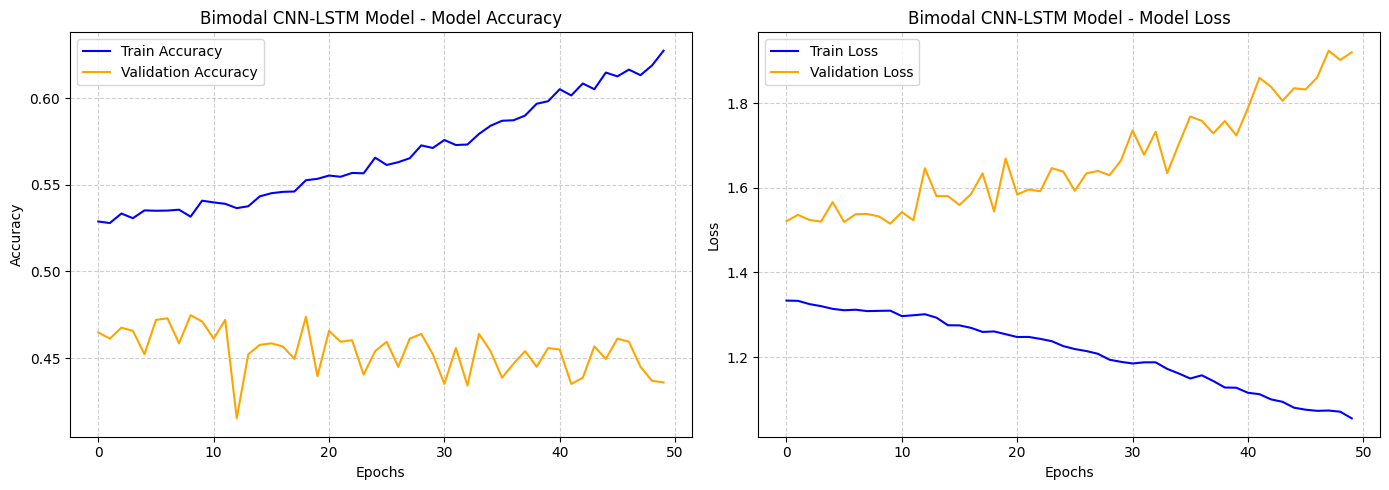


================ Evaluating Bimodal CNN-LSTM Model ================

--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.29      0.29      0.29       345
     disgust       0.08      0.01      0.03        68
        fear       0.00      0.00      0.00        50
         joy       0.42      0.64      0.51       402
     neutral       0.62      0.70      0.66      1256
     sadness       0.28      0.08      0.13       208
    surprise       0.19      0.09      0.12       281

    accuracy                           0.49      2610
   macro avg       0.27      0.26      0.25      2610
weighted avg       0.45      0.49      0.46      2610



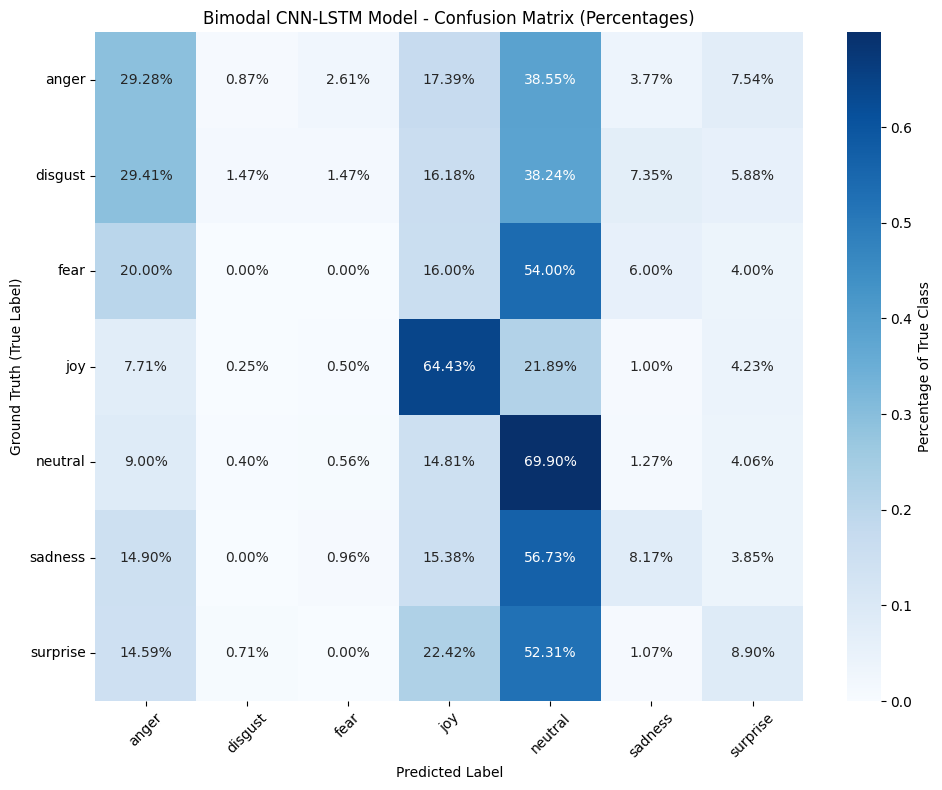

In [20]:
# ==========================================
# 4. EVALUATE
# ==========================================
plot_training_history(history_cnn_lstm, "Bimodal CNN-LSTM Model")
evaluate_model_performance(cnn_lstm_model, [X_test_mfcc, X_test_stats, X_test_txt], y_test, "Bimodal CNN-LSTM Model")

### 1. Modality ablation — test the "text branch is doing all the work" hypothesis
Run inference three times, each time zeroing out one branch's input, and compare accuracy drop:

In [22]:
def eval_with_branch_masked(model, X_mfcc, X_stats, X_txt, y, mask_branch=None):
    Xm, Xs, Xt = X_mfcc.copy(), X_stats.copy(), X_txt.copy()
    if mask_branch == "mfcc":
        Xm[:] = 0
    elif mask_branch == "stats":
        Xs[:] = 0
    elif mask_branch == "text":
        Xt[:] = 0
    loss, acc = model.evaluate([Xm, Xs, Xt], y, verbose=0)
    return acc

baseline_acc = cnn_lstm_model.evaluate([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev, verbose=0)[1]
acc_no_mfcc  = eval_with_branch_masked(cnn_lstm_model, X_dev_mfcc, X_dev_stats, X_dev_txt, y_dev, "mfcc")
acc_no_stats = eval_with_branch_masked(cnn_lstm_model, X_dev_mfcc, X_dev_stats, X_dev_txt, y_dev, "stats")
acc_no_text  = eval_with_branch_masked(cnn_lstm_model, X_dev_mfcc, X_dev_stats, X_dev_txt, y_dev, "text")

print(f"Baseline (all branches):     {baseline_acc:.4f}")
print(f"Text branch zeroed:         {acc_no_text:.4f}  (drop = {baseline_acc-acc_no_text:.4f})")
print(f"MFCC branch zeroed:         {acc_no_mfcc:.4f}  (drop = {baseline_acc-acc_no_mfcc:.4f})")
print(f"Stats branch zeroed:        {acc_no_stats:.4f}  (drop = {baseline_acc-acc_no_stats:.4f})")

Baseline (all branches):     0.4359
Text branch zeroed:         0.3745  (drop = 0.0614)
MFCC branch zeroed:         0.3962  (drop = 0.0397)
Stats branch zeroed:        0.1354  (drop = 0.3005)


### 2. Permutation importance (more rigorous than zeroing)
Zeroing can be an out-of-distribution input the model has never seen. Permutation (shuffling that branch's values across the batch) keeps the same distribution:

In [23]:
def permutation_importance(model, X_mfcc, X_stats, X_txt, y, branch, n_repeats=5):
    baseline = model.evaluate([X_mfcc, X_stats, X_txt], y, verbose=0)[1]
    drops = []
    for _ in range(n_repeats):
        idx = np.random.permutation(len(y))
        Xm, Xs, Xt = X_mfcc.copy(), X_stats.copy(), X_txt.copy()
        if branch == "mfcc": Xm = Xm[idx]
        elif branch == "stats": Xs = Xs[idx]
        elif branch == "text": Xt = Xt[idx]
        acc = model.evaluate([Xm, Xs, Xt], y, verbose=0)[1]
        drops.append(baseline - acc)
    return np.mean(drops), np.std(drops)

for branch in ["mfcc", "stats", "text"]:
    mean_drop, std_drop = permutation_importance(cnn_lstm_model, X_dev_mfcc, X_dev_stats, X_dev_txt, y_dev, branch)
    print(f"{branch:6s}: mean accuracy drop = {mean_drop:.4f} ± {std_drop:.4f}")

mfcc  : mean accuracy drop = 0.0439 ± 0.0109
stats : mean accuracy drop = 0.0016 ± 0.0078
text  : mean accuracy drop = 0.1103 ± 0.0113


In [24]:
print("Stats feature means:", X_dev_stats.mean(axis=0)[:5])
print("Stats feature stds:", X_dev_stats.std(axis=0)[:5])

Stats feature means: [0.28115165 0.2755412  0.2753242  0.28255787 0.28809705]
Stats feature stds: [0.12670399 0.12438951 0.12287766 0.12360775 0.12579729]


### 3. Investigate why stats contributes nothing 
— worth checking whether the stats features themselves carry emotion-relevant signal at all, independent of the model:

In [26]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=SEED)
rf.fit(X_train_stats, y_train)
print("Stats-only RF dev accuracy:", rf.score(X_dev_stats, y_dev))

Stats-only RF dev accuracy: 0.4187725631768953


### 4. CONFUSION MATRIX: within-valence vs cross-valence error analysis

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
CLASSIFICATION REPORT (Dev Set)
              precision    recall  f1-score   support

       anger      0.299     0.320     0.309       153
     disgust      0.000     0.000     0.000        22
        fear      0.000     0.000     0.000        40
         joy      0.336     0.515     0.407       163
     neutral      0.562     0.716     0.630       469
     sadness      0.250     0.045     0.076       111
    surprise      0.158     0.060     0.087       150

    accuracy                          0.436      1108
   macro avg      0.229     0.237     0.216      1108
weighted avg      0.375     0.436     0.389      1108



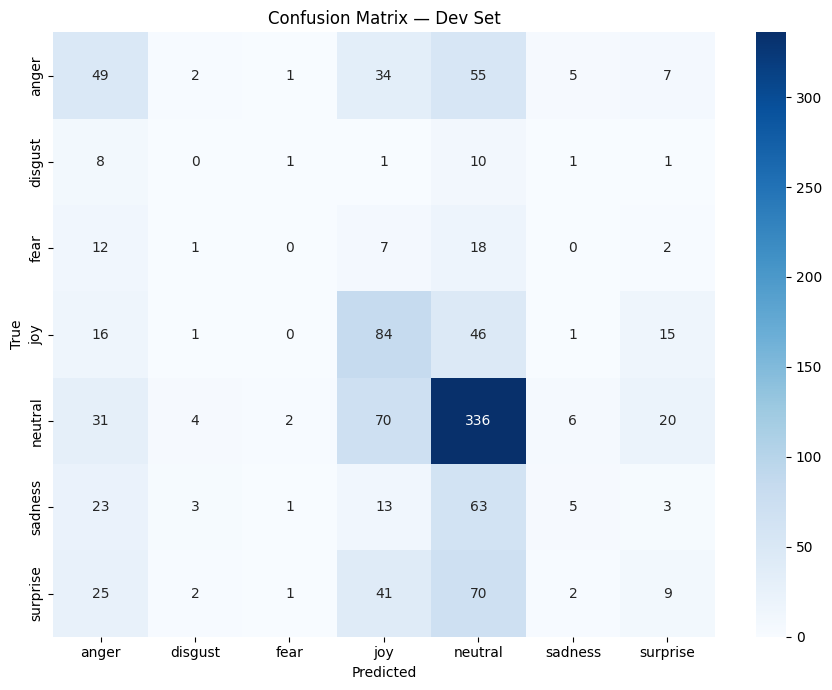


ERROR BREAKDOWN BY VALENCE
Correct predictions        : 483 (0.4359)
Within-valence errors      : 114 (0.1029)
Cross-valence errors       : 511 (0.4612)
Total errors               : 625

Of all errors, 18.2% stay within the same valence group


In [32]:
# ==========================================
# CONFUSION MATRIX: within-valence vs cross-valence error analysis
# ==========================================
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Define emotion label order (must match your label encoding, e.g., LabelEncoder classes_)
emotion_labels = ['anger', 'disgust', 'fear', 'joy', 'neutral', 'sadness', 'surprise']

# Get model predictions on the dev set
y_pred_probs = cnn_lstm_model.predict([X_dev_mfcc, X_dev_stats, X_dev_txt])
y_pred = np.argmax(y_pred_probs, axis=1)

# Full classification report
print("=" * 60)
print("CLASSIFICATION REPORT (Dev Set)")
print("=" * 60)
print(classification_report(y_dev, y_pred, target_names=emotion_labels, digits=3))

# Confusion matrix
cm = confusion_matrix(y_dev, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=emotion_labels, yticklabels=emotion_labels)
plt.title("Confusion Matrix — Dev Set")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ==========================================
# Group emotions into valence buckets and quantify within- vs cross-valence errors
# ==========================================
valence_map = {
    'joy': 'positive',
    'surprise': 'positive',      # surprise is ambiguous but often grouped positive in MELD's own sentiment mapping
    'neutral': 'neutral',
    'anger': 'negative',
    'disgust': 'negative',
    'fear': 'negative',
    'sadness': 'negative'
}

within_valence_errors = 0
cross_valence_errors = 0
correct = 0

for true_idx, pred_idx in zip(y_dev, y_pred):
    true_label = emotion_labels[true_idx]
    pred_label = emotion_labels[pred_idx]

    if true_label == pred_label:
        correct += 1
    elif valence_map[true_label] == valence_map[pred_label]:
        within_valence_errors += 1
    else:
        cross_valence_errors += 1

total = len(y_dev)
print("\n" + "=" * 60)
print("ERROR BREAKDOWN BY VALENCE")
print("=" * 60)
print(f"Correct predictions        : {correct} ({correct/total:.4f})")
print(f"Within-valence errors      : {within_valence_errors} ({within_valence_errors/total:.4f})")
print(f"Cross-valence errors       : {cross_valence_errors} ({cross_valence_errors/total:.4f})")
print(f"Total errors               : {within_valence_errors + cross_valence_errors}")
print(f"\nOf all errors, {within_valence_errors / (within_valence_errors + cross_valence_errors):.1%} stay within the same valence group")

## BAN Model (Training & Testing)

In [15]:
# ==========================================
# 1. DEFINE INPUT BRANCHES
# ==========================================
# Branch 1: Acoustic MFCCs (Time-Series)
in_mfcc = layers.Input(shape=(Config.MAX_MFCC_LEN, Config.N_MFCC), name="in_mfcc")
x_mfcc = layers.Conv1D(64, 3, activation='relu', padding='same')(in_mfcc)
x_mfcc = layers.MaxPooling1D(2)(x_mfcc)
x_mfcc = layers.LSTM(64)(x_mfcc)

# Branch 2: Acoustic Statistical Features (Numeric)
in_stats = layers.Input(shape=(X_train_stats.shape[1],), name="in_stats")
x_stats = layers.Dense(32, activation='relu')(in_stats)
x_stats = layers.BatchNormalization()(x_stats)

# Combine Acoustic Features
x_audio_combined = layers.Concatenate()([x_mfcc, x_stats])
# Project combined audio to a fixed dimension (64) for attention matching
x_audio_proj = layers.Dense(64, activation='relu')(x_audio_combined)

# Branch 3: Textual Sentiment (One-Hot Encoded)
in_text = layers.Input(shape=(X_train_txt.shape[1],), name="in_text")
# Project the text input into the same dimensional space (64)
x_text = layers.Dense(64, activation='relu')(in_text) 

# ==========================================
# 2. CROSS-MODAL ATTENTION MECHANISM
# ==========================================
# The text features generate a sigmoid attention mask (values between 0 and 1)
attention_weights = layers.Dense(64, activation='sigmoid', name="text_guided_attention")(x_text)

# The attention mask is multiplied element-wise against the combined audio features.
# This forces the network to "pay attention" to specific audio signals based on the text sentiment.
attended_audio = layers.Multiply(name="attended_audio")([x_audio_proj, attention_weights])

# ==========================================
# 3. FUSION AND CLASSIFICATION
# ==========================================
# Concatenate the text-focused audio back with the original text context
merged = layers.Concatenate()([attended_audio, x_text])

# Fully Connected Layers
x = layers.Dense(128, activation='relu')(merged)
x = layers.Dropout(Config.DROPOUT)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Build the final BAN Model
ban_model = models.Model(inputs=[in_mfcc, in_stats, in_text], outputs=outputs)

In [21]:
# ==========================================
# 4. COMPILE AND TRAIN
# ==========================================
optimizer = optimizers.Adam(learning_rate=Config.LEARNING_RATE)
ban_model.compile(optimizer=optimizer, 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])

print(f"Training BAN for exactly {Config.EPOCHS} epochs...")
history_ban = ban_model.fit(
    [X_train_mfcc, X_train_stats, X_train_txt], y_train,  
    validation_data=([X_dev_mfcc, X_dev_stats, X_dev_txt], y_dev),
    epochs=Config.EPOCHS,
    batch_size=Config.BATCH_SIZE,
    verbose=1
)

Training BAN for exactly 50 epochs...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5428 - loss: 1.2771 - val_accuracy: 0.4684 - val_loss: 1.5470
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5433 - loss: 1.2734 - val_accuracy: 0.4819 - val_loss: 1.5422
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5468 - loss: 1.2768 - val_accuracy: 0.4404 - val_loss: 1.6303
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5452 - loss: 1.2634 - val_accuracy: 0.4513 - val_loss: 1.6383
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.5480 - loss: 1.2596 - val_accuracy: 0.4657 - val_loss: 1.5656
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5530 - loss: 1.2467 - val_accuracy: 0.4558 - val_loss: 1.5922
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.5533 - loss: 1.2473 - val_accuracy: 0.4711 - val_loss: 1.5818
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 

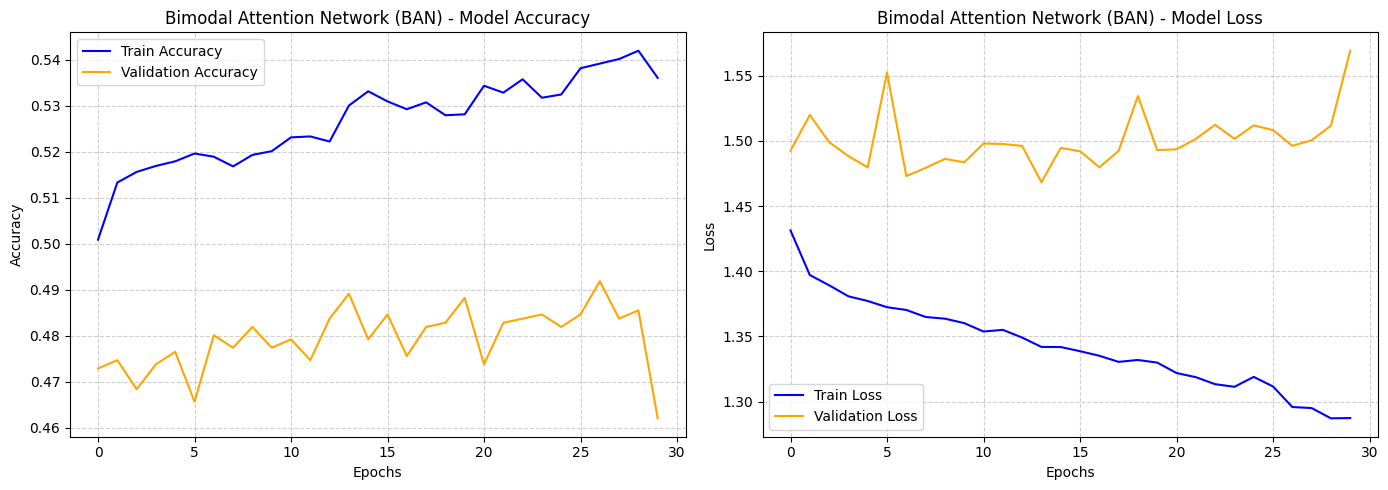


================ Evaluating Bimodal Attention Network (BAN) ================

--- Classification Report ---
              precision    recall  f1-score   support

       anger       0.29      0.38      0.33       345
     disgust       0.00      0.00      0.00        68
        fear       0.00      0.00      0.00        50
         joy       0.43      0.64      0.52       402
     neutral       0.63      0.70      0.66      1256
     sadness       0.28      0.12      0.16       208
    surprise       0.17      0.05      0.08       281

    accuracy                           0.50      2610
   macro avg       0.26      0.27      0.25      2610
weighted avg       0.45      0.50      0.46      2610



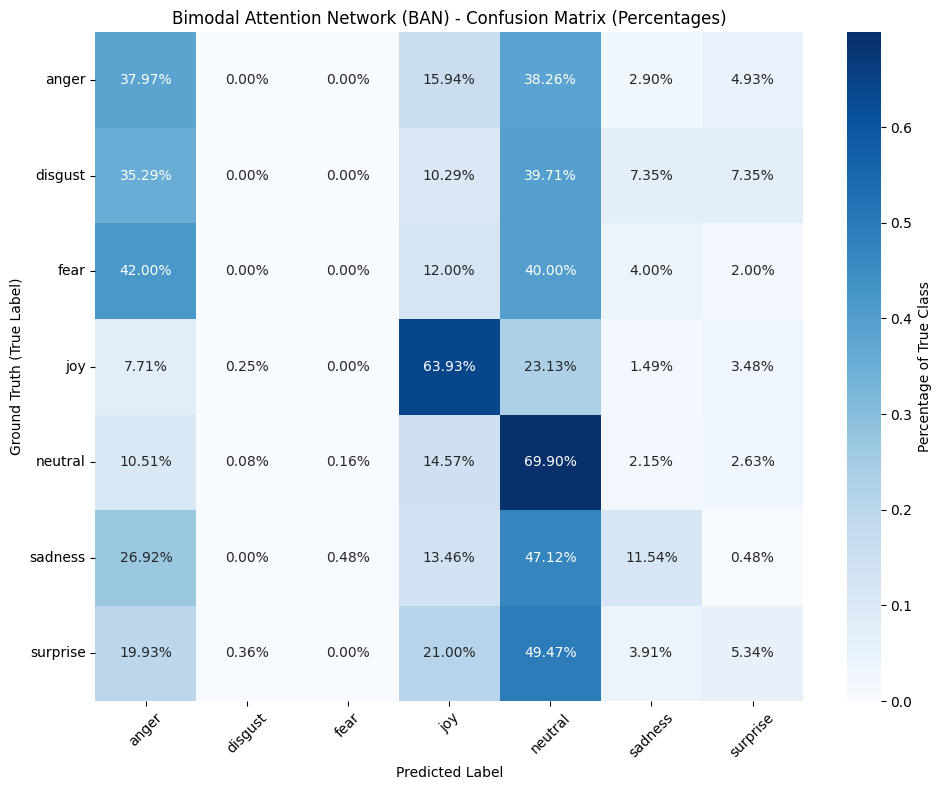

In [17]:
# ==========================================
# 5. EVALUATE
# ==========================================
plot_training_history(history_ban, "Bimodal Attention Network (BAN)")
evaluate_model_performance(ban_model, [X_test_mfcc, X_test_stats, X_test_txt], y_test, "Bimodal Attention Network (BAN)")